In [5]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import statistics as st
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore") # not to display warnings

In [6]:
# Load the data
df=pd.read_csv(r'C:\Users\User\Downloads\winequality-red.csv', sep=';') # sep=';' -> definir separador correto dos dados (;)
# Explore the file
df.info()
df.head() # -> primeiras 5 linhas
# df.tail() -> últimas 5 linhas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


O dataset tem 1599 linhas e 12 colunas.

As variáveis são fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol e quality.

Existe 1 tipo de variável:

- Variáveis quantitativas (numéricas): fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol e quality

Não existem valores em falta.

In [11]:
# Obtenha um resumo das estatísticas descritivas básicas de todas as variáveis numéricas em winequality-red.csv.
df.describe() 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Variável quality:
- Média: 5.6
- Mediana: 6.0
- Desvio padrão: 0.8

Variável alcohol:
- Mínimo: 8.40
- Máximo: 14.90

Variável pH:
- Média: 3.311

Na variável quality, a média é muito próxima da mediana, o que mostra que a maioria dos vinhos apresenta qualidade média, existindo poucos vinhos com qualidade muito baixa ou muito elevada.

In [14]:
df.quality.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

A qualidade mais frequente é 5, o que indica que a maioria dos vinhos apresenta qualidade média. Existem poucos vinhos com qualidade muito baixa ou muito elevada.

In [16]:
# Teor alcoólico médio por nível de qualidade
df.groupby('quality')['alcohol'].mean()

quality
3     9.955000
4    10.265094
5     9.899706
6    10.629519
7    11.465913
8    12.094444
Name: alcohol, dtype: float64

De um modo geral, observa-se que, quanto maior a qualidade do vinho, maior tende a ser o teor alcoólico.

No entanto, esta relação não é perfeitamente linear, pois existem algumas variações (por exemplo, entre as qualidades 4 e 5).

In [19]:
# Acidez volátil média por nível de qualidade
df.groupby('quality')['volatile acidity'].mean()

quality
3    0.884500
4    0.693962
5    0.577041
6    0.497484
7    0.403920
8    0.423333
Name: volatile acidity, dtype: float64

Os vinhos com menor acidez volátil tendem a ter melhor qualidade.

In [21]:
# Selecionar vinhos com qualidade maior ou igual a 7
df[df['quality']>= 7]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.99460,3.39,0.47,10.00,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.99680,3.36,0.57,9.50,7
16,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.50,7
37,8.1,0.38,0.28,2.1,0.066,13.0,30.0,0.99680,3.23,0.73,9.70,7
62,7.5,0.52,0.16,1.9,0.085,12.0,35.0,0.99680,3.38,0.62,9.50,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1541,7.4,0.25,0.29,2.2,0.054,19.0,49.0,0.99666,3.40,0.76,10.90,7
1544,8.4,0.37,0.43,2.3,0.063,12.0,19.0,0.99550,3.17,0.81,11.20,7
1549,7.4,0.36,0.30,1.8,0.074,17.0,24.0,0.99419,3.24,0.70,11.40,8
1555,7.0,0.56,0.17,1.7,0.065,15.0,24.0,0.99514,3.44,0.68,10.55,7


In [22]:
# Nº de vinhos com qualidade maior ou igual a 7
df[df['quality']>= 7].shape

(217, 12)

O número de vinhos com qualidade maior ou igual a 7 é 217.

In [24]:
# Álcool Médio quando qualidade é maior ou igual a 7
round(df[df['quality']>= 7]['alcohol'].mean(), 2)

11.52

O álcool médio nos vinhos com qualidade maior ou igual a 7 é 11.52, sendo superior à média geral (aproximadamente 10.42).

In [26]:
# Vinhos com teor alcoólico superior a 14
df[df['alcohol']>14]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
652,15.9,0.36,0.65,7.5,0.096,22.0,71.0,0.9976,2.98,0.84,14.9,5


In [27]:
# Nº de vinhos com teor alcoólico superior a 14
df[df['alcohol']>14].shape

(1, 12)

O número de vinhos com teor alcoólico superior a 14 é 1.

Existem muito poucos vinhos com teor alcoólico muito elevado (superior a 14), sendo apenas um caso, o que indica que valores extremos de álcool são raros.

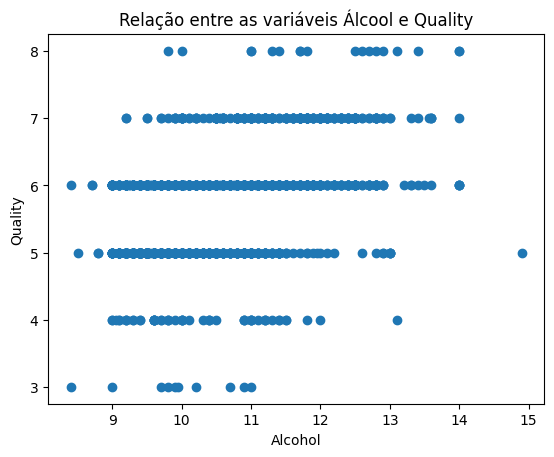

In [30]:
# Gráfico de dispersão para avaliar a relação entre alcohol e quality
fig, axes = plt.subplots(nrows=1, ncols=1)

axes.scatter(df['alcohol'], df['quality'])
axes.set_title('Relação entre as variáveis Álcool e Quality')
axes.set_xlabel('Alcohol')
axes.set_ylabel('Quality')

plt.show()

O gráfico de dispersão mostra alguma dispersão dos pontos e uma relação positiva fraca entre o álcool e a qualidade. Observa-se que vinhos com maior teor alcoólico tendem a ter qualidade mais elevada.

Relação Positiva Fraca:
- Positiva: quando uma variável aumenta, a outra tende também a aumentar
- Fraca: essa tendência existe, mas há muita dispersão nos dados

In [33]:
# Cálculo do coeficiente de correlação de Pearson entre alcohol e quality
pearson_corr, _ = pearsonr(df['alcohol'], df['quality'])
print("O coeficiente de correlação de Pearson entre alcohol e quality é", "{:.3f}".format(pearson_corr))

O coeficiente de correlação de Pearson entre alcohol e quality é 0.476


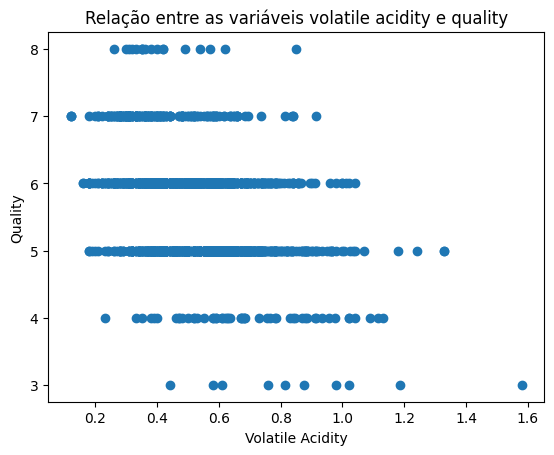

In [34]:
# Gráfico de dispersão para avaliar a relação entre volatile acidity e quality
fig, axes = plt.subplots(nrows=1, ncols=1)

axes.scatter(df['volatile acidity'], df['quality'])
axes.set_title('Relação entre as variáveis volatile acidity e quality')
axes.set_xlabel('Volatile Acidity')
axes.set_ylabel('Quality')

plt.show()

O gráfico de dispersão mostra alguma dispersão dos pontos e uma relação negativa fraca entre a acidez volátil e a qualidade. Observa-se que vinhos com maior acidez volátil tendem a ter qualidade mais baixa.

Relação Negativa Fraca:
- Negativa: quando uma variável aumenta, a outra tende a diminuir
- Fraca: essa tendência existe, mas há muita dispersão nos dados

In [37]:
# Cálculo do coeficiente de correlação de Pearson entre volatile acidity e quality
pearson_corr, _ = pearsonr(df['volatile acidity'], df['quality'])
print("O coeficiente de correlação de Pearson entre volatile acidity e quality é", "{:.3f}".format(pearson_corr))

O coeficiente de correlação de Pearson entre volatile acidity e quality é -0.391


Text(0, 0.5, 'Frequência relativa')

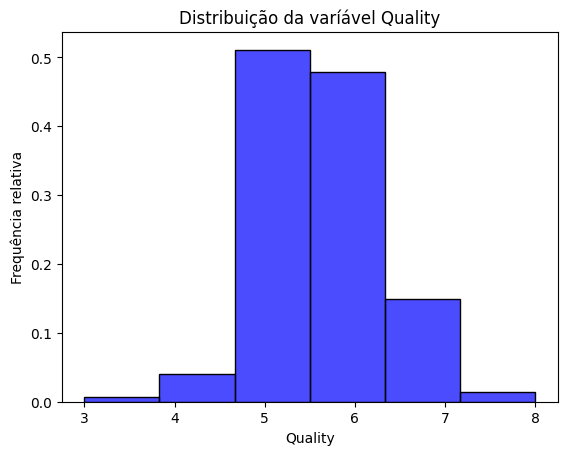

In [38]:
# Histograma da variável quality
fig, ax = plt.subplots()

sns.histplot(df['quality'], bins=6, color='blue', alpha=0.7, kde=False, stat='density', ax=ax)
ax.set_title('Distribuição da varíável Quality')
ax.set_xlabel('Quality')
ax.set_ylabel('Frequência relativa')

No histograma da distribuição da variável Quality é aproximadamente unimodal e concentrada entre os valores 5 e 6, o que indica que a maioria dos vinhos possui qualidade intermediária.

Text(0.5, 1.0, 'Mapa de correlação')

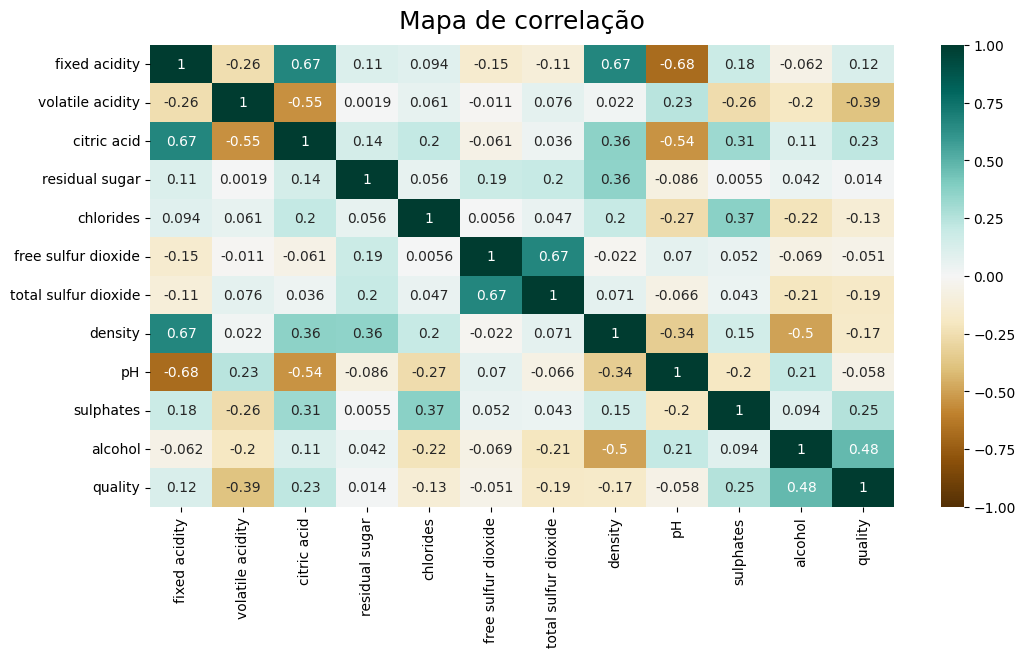

In [40]:
# Apresentação de uma matriz de correlação para todas as variáveis numéricas em *WineQuality-red*.
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Mapa de correlação', fontdict={'fontsize':18}, pad=12)

O mapa de correlação mostra que as correlações entre as variáveis são, em geral, fracas.

Em particular, a variável quality apresenta correlações mais relevantes com algumas variáveis, como o álcool (relação positiva fraca) e a acidez volátil (relação negativa fraca).

Nenhuma variável isolada explica totalmente a qualidade do vinho. A variável quality parece depender de vários fatores ao mesmo tempo, e não apenas de álcool ou acidez volátil.

Text(0.5, 1.0, 'Distribuição da variável Quality')

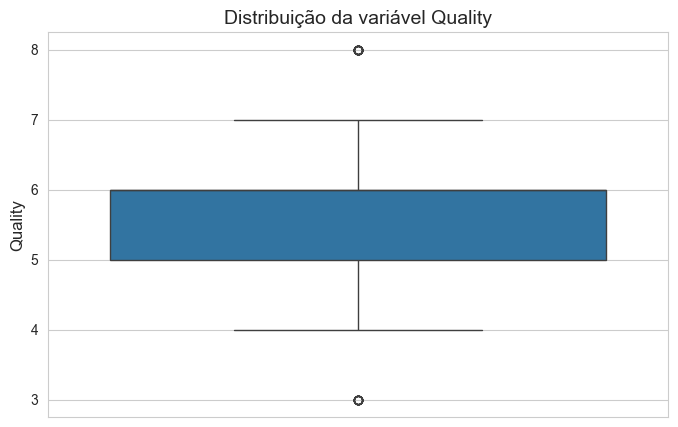

In [43]:
# Boxplot da area
sns.set_style('whitegrid') # selecionar o tema, facultativo
plt.figure(figsize=(8,5)) # fixar a dimensão da figura, facultativo

sns.boxplot(df['quality'])
plt.ylabel("Quality", size=12)
plt.title("Distribuição da variável Quality", size=14)

O boxplot da variável quality mostra uma mediana entre 5 e 6, baixa variabilidade na maioria dos dados e uma distribuição aproximadamente simétrica, com poucos outliers.

In [45]:
# Amplitude inter-quartil da qualidade dos vinhos
q_25 = np.quantile(df['quality'], 0.25) 
q_75 = np.quantile(df['quality'], 0.75) 

IQR=q_75-q_25
print("A amplitude inter-quartil da qualidade dos vinhos é", IQR)

A amplitude inter-quartil da qualidade dos vinhos é 1.0


In [46]:
# Existência de outliers
bi=np.quantile(df['quality'], 0.25)-1.5*(np.quantile(df['quality'], 0.75)-np.quantile(df['quality'], 0.25)) # BI=Q1-1,5×IQR (para outliers inferiores)
print(bi)

bs=np.quantile(df['quality'], 0.75)+1.5*(np.quantile(df['quality'], 0.75)-np.quantile(df['quality'], 0.25)) # BS=Q3+1,5×IQR (para outliers superiores)
print(bs)

outliers = df[(df['quality'] < bi) | (df['quality'] > bs)]
outliers.shape

3.5
7.5


(28, 12)

Os limites definidos pelo critério do IQR são 3.5 (inferior) e 7.5 (superior). 

Foram identificados 28 outliers, correspondentes a valores de qualidade que se encontram fora do intervalo esperado.

Estes resultados indicam a presença de poucos valores extremos e uma distribuição aproximadamente simétrica.

In [49]:
# Coeficiente assimetria da qualidade dos vinhos
from scipy.stats import skew
assimetria=skew(df['quality'],axis=0,bias=True) # Eixo ao longo do qual o valor da assimetria deve ser medido (por defeito, 0).
print("O coeficiente de assimetria da qualidade dos vinhos é", "{:.3f}".format(assimetria))

O coeficiente de assimetria da qualidade dos vinhos é 0.218


A variável quality apresenta um coeficiente de assimetria próximo de zero (0.218), o que indica uma distribuição aproximadamente simétrica.

In [51]:
# Verificar valores em falta
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Não foram identificados valores em falta no conjunto de dados.

In [53]:
# Verificar duplicados
df.duplicated().sum() 

240

Foram identificadas 240 valores duplicados, o que indica a presença de observações repetidas que influenciam a análise e devem por isso ser removidas.

In [55]:
# Remover linhas duplicadas
df = df.drop_duplicates()
df.shape

(1359, 12)

Após a remoção dos valores duplicados, o conjunto de dados passou a conter 1359 amostras.

In [ ]:
# Agrupar categorias raras (quality 3 e 8 têm muito poucas observações)
print(df['quality'].value_counts())

# quality 3: 10 casos (~0.7%), quality 8: 18 casos (~1.3%) 
df = df[df['quality'].between(4, 7)]
print(df.shape)

São removidos os vinhos com qualidade 3 e 8 por representarem categorias raras (menos de 5% das observações), o que concentra a análise nas categorias com observações suficientes (4, 5, 6 e 7).

In [83]:
# Variáveis independentes e dependente
x = df[['alcohol', 'volatile acidity', 'sulphates',
        'citric acid', 'density', 'pH']]
y = df['quality']

# Dividir treino (80%) e teste (20%) 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0)

Para a modelação, selecionaram-se as variáveis independentes com maior correlação com a qualidade do vinho (alcohol, volatile acidity, sulphates, citric acid, density e pH), sendo o conjunto de dados dividido em 80% para treino e 20% para teste.

In [86]:
# Estimar modelo OLS completo
x_train_sm = sm.add_constant(x_train)
model = sm.OLS(y_train, x_train_sm).fit()
print(model.summary())
# Analisar p-values: rejeitar H0 se p < 0.05 -> variável significativa

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     108.2
Date:                Thu, 14 May 2026   Prob (F-statistic):          8.23e-107
Time:                        10:27:53   Log-Likelihood:                -1072.0
No. Observations:                1087   AIC:                             2158.
Df Residuals:                    1080   BIC:                             2193.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -19.7023     15.048  

O modelo OLS completo foi estimado com 6 variáveis independentes, usando 1087 observações de treino.
O modelo apresenta um R² de 0.375, o que significa que aproximadamente 37.5% da variabilidade da qualidade do vinho é explicada pelas variáveis independentes selecionadas. O valor de Prob (F-statistic) = 8.23e-107 < 0.05, pelo que se rejeita H0 e conclui-se que o modelo é globalmente significativo.

Analisando os p-values de cada variável (P>|t|), com α = 0.05:

- alcohol -> p = 0.000 < 0.05 -> significativa
- volatile acidity -> p = 0.000 < 0.05 -> significativa
- sulphates -> p = 0.000 < 0.05 -> significativa
- citric acid -> p = 0.001 < 0.05 -> significativa
- density -> p = 0.115 > 0.05 -> não significativa
- pH -> p = 0.000 < 0.05 -> significativa

A variável density não é estatisticamente significativa, pelo que será removida no modelo parsimonioso.

In [91]:
# Modelo parsimonioso - remover variáveis com p > 0.05
# Manter apenas as significativas
x_train_pars = x_train[['alcohol', 'volatile acidity', 'sulphates']]
x_train_pars = sm.add_constant(x_train_pars)
model_pars = sm.OLS(y_train, x_train_pars).fit()
print(model_pars.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     208.4
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.08e-106
Time:                        10:31:11   Log-Likelihood:                -1080.2
No. Observations:                1087   AIC:                             2168.
Df Residuals:                    1083   BIC:                             2188.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.1761      0.234  

O modelo parsimonioso foi estimado removendo a variável density (não significativa no modelo completo), ficando apenas com as 3 variáveis significativas: alcohol, volatile acidity e sulphates.

O modelo apresenta um R² de 0.366, ou seja, explica aproximadamente 36.6% da variabilidade da qualidade do vinho. O Prob (F-statistic) = 1.08e-106 < 0.05, pelo que o modelo é globalmente significativo.
Todas as variáveis são estatisticamente significativas (p = 0.000 < 0.05), confirmando a sua relevância no modelo final. Interpretando os coeficientes:

- alcohol (0.3439) -> cada unidade adicional de álcool aumenta a qualidade esperada em 0.34 unidades
- volatile acidity (-1.1364) -> cada unidade adicional de acidez volátil diminui a qualidade esperada em 1.14 unidades
- sulphates (0.7094) -> cada unidade adicional de sulfatos aumenta a qualidade esperada em 0.71 unidades

Estes resultados são consistentes com a análise exploratória, onde se verificou que vinhos com maior teor alcoólico e menor acidez volátil tendem a ter melhor qualidade. Comparando com o modelo completo, a redução do R² é mínima (0.375 -> 0.366), o que confirma que a variável removida não acrescentava valor explicativo relevante

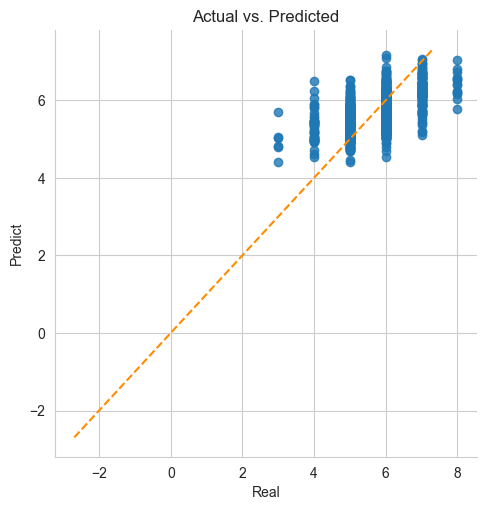

In [94]:
# PRESSUPOSTOS 

# 1. Linearidade - Actual vs Predicted
Predict = model_pars.predict(x_train_pars)
Residuals = y_train - Predict

data_results = {'Real': y_train,
                'Predict': Predict,
                'Residuals': Residuals}
df_results = pd.DataFrame(data_results)

sns.lmplot(x='Real', y='Predict', data=df_results, fit_reg=False)
line_coords = np.arange(df_results.min().min(), df_results.max().max())
plt.plot(line_coords, line_coords, color='darkorange', linestyle='--')
plt.title('Actual vs. Predicted')
plt.show()

Pressuposto 1- Linearidade

O gráfico Actual vs. Predicted mostra que os pontos seguem de forma geral a diagonal, sugerindo que o pressuposto de linearidade é satisfeito. A distribuição em colunas verticais é esperada dado que a variável quality é discreta.

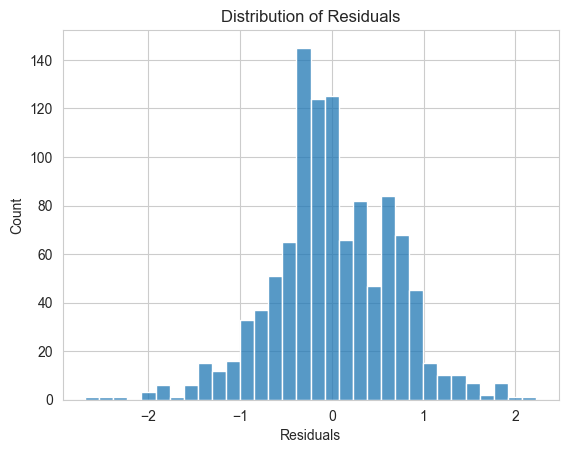

In [97]:
# 2. Normalidade dos resíduos
plt.title('Distribution of Residuals')
sns.histplot(df_results['Residuals'])
plt.show()

Pressuposto 2- Normalidade dos resíduos

O histograma dos resíduos apresenta uma distribuição aproximadamente centrada em zero, com uma ligeira assimetria à esquerda. O pressuposto de normalidade é considerado razoavelmente satisfeito.

In [101]:
# 3. Multicolinearidade (VIF)
# VIF < 10 -> ausência de multicolinearidade
df_vif = df.rename(columns={'volatile acidity': 'volatile_acidity'})
y_vif, X_vif = dmatrices(
    'quality ~ alcohol + volatile_acidity + sulphates',
    data=df_vif, return_type='dataframe')

vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]
vif['variable'] = X_vif.columns
print(vif)

          VIF          variable
0  136.675086         Intercept
1    1.042657           alcohol
2    1.106990  volatile_acidity
3    1.072678         sulphates


Pressuposto 3- Multicolinearidade (VIF)

Os valores de VIF das três variáveis são todos inferiores a 10 (alcohol: 1.04, volatile acidity: 1.11, sulphates: 1.07), o que indica ausência de multicolinearidade. As variáveis independentes não estão fortemente correlacionadas entre si, pelo que o pressuposto é satisfeito.

In [104]:
# 4. Autocorrelação dos resíduos (Durbin-Watson)
# Valores entre 1.5 e 2.5 -> sem autocorrelação
dw_stat = durbin_watson(df_results['Residuals'])
print(f"Estatística de Durbin-Watson: {dw_stat:.4f}")

Estatística de Durbin-Watson: 2.0792


Pressuposto 4- Ausência de autocorrelação (Durbin-Watson)

O valor da estatística de Durbin-Watson é 2.079, encontrando-se dentro do intervalo esperado [1.5, 2.5], pelo que não se rejeita H0 e conclui-se que não existe autocorrelação nos resíduos. O pressuposto é satisfeito.

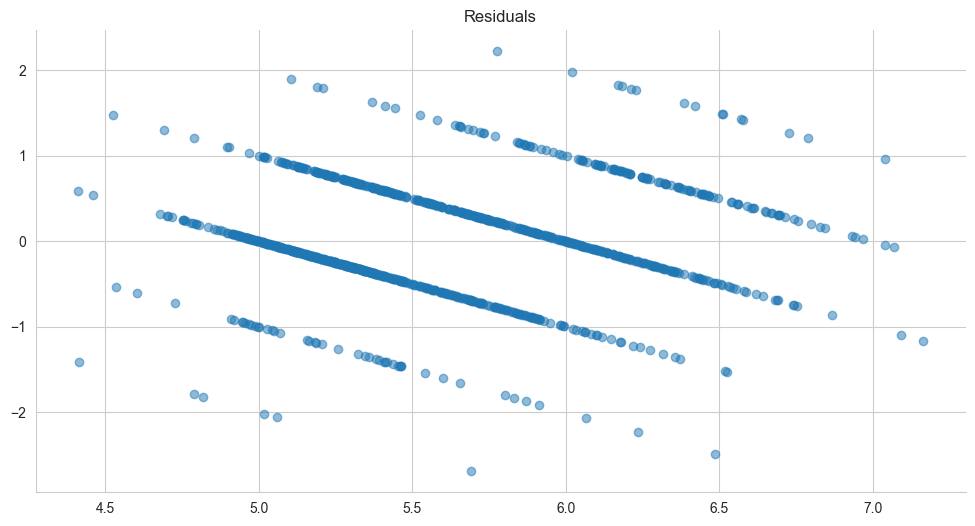

In [107]:
# 5. Homoscedasticidade
plt.subplots(figsize=(12, 6))
ax = plt.subplot(111)
plt.scatter(x=df_results['Predict'], y=df_results['Residuals'], alpha=0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.title('Residuals')
plt.show()

Pressuposto 5- Homoscedasticidade

O gráfico dos resíduos apresenta um padrão estruturado em bandas diagonais, o que indica heteroscedasticidade- a variância dos resíduos não é constante. Este comportamento é expectável dado que a variável quality é discreta, o que faz com que os resíduos se agrupem em padrões fixos. O pressuposto de homoscedasticidade não é totalmente satisfeito.

In [119]:
# Performance do modelo estatístico
x_test_pars = x_test[['alcohol', 'volatile acidity', 'sulphates']]
x_test_pars = sm.add_constant(x_test_pars)
Predict_test = model_pars.predict(x_test_pars)

MSE = st.mean((y_test - Predict_test.values)**2)
MAE = st.mean(abs(y_test - Predict_test.values))
MAPE = st.mean((abs((y_test - Predict_test.values) / y_test)) * 100)
print("Mean square error =", MSE)
print("Mean absolute error =", MAE)
print("Mean absolute percentual error =", MAPE)

Mean square error = 0.5246448332192382
Mean absolute error = 0.5660930783252343
Mean absolute percentual error = 10.572122662048129


O modelo apresenta um MSE de 0.52, um MAE de 0.57 e um MAPE de 10.57%, indicando que o erro médio de previsão da qualidade do vinho é de aproximadamente 10.6%, considerado razoável para uma escala de 4 a 7.

In [122]:
# Normalização
# Necessária para SVR (modelo baseado em distâncias)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [124]:
# Treinar modelos
# Escolha justificada: os mais adequados para regressão com relações não lineares

model1 = LinearRegression()                                    # baseline simples
model1.fit(x_train_scaled, y_train)

model2 = RandomForestRegressor(n_estimators=100, random_state=42)  # robusto a outliers
model2.fit(x_train_scaled, y_train)

model3 = SVR(kernel='rbf')                                     # relações não lineares
model3.fit(x_train_scaled, y_train)

SVR()

A justificação para a escolha dos 3 modelos é:

- LinearRegression- serve como baseline simples de comparação
- RandomForestRegressor- robusto a outliers e adequado para dados complexos
- SVR(kernel='rbf')- adequado para relações não lineares

In [127]:
# Avaliar modelos
y_pred1 = model1.predict(x_test_scaled)
y_pred2 = model2.predict(x_test_scaled)
y_pred3 = model3.predict(x_test_scaled)

mse1 = mean_squared_error(y_test, y_pred1)
r21  = r2_score(y_test, y_pred1)
print(f"MSE Linear Regression: {mse1:.4f}")
print(f"R2  Linear Regression: {r21:.4f}")

mse2 = mean_squared_error(y_test, y_pred2)
r22  = r2_score(y_test, y_pred2)
print(f"MSE Random Forest: {mse2:.4f}")
print(f"R2  Random Forest: {r22:.4f}")

mse3 = mean_squared_error(y_test, y_pred3)
r23  = r2_score(y_test, y_pred3)
print(f"MSE SVR: {mse3:.4f}")
print(f"R2  SVR: {r23:.4f}")

MSE Linear Regression: 0.5357
R2  Linear Regression: 0.2266
MSE Random Forest: 0.5331
R2  Random Forest: 0.2303
MSE SVR: 0.4925
R2  SVR: 0.2890


Os três modelos apresentam desempenhos semelhantes, sendo o SVR o melhor com MSE de 0.4925 e R² de 0.2890, seguido do Random Forest (MSE: 0.5331, R²: 0.2303) e da Linear Regression (MSE: 0.5357, R²: 0.2266). O SVR é escolhido como modelo final por apresentar o menor erro e maior poder explicativo, ainda que os valores de R² relativamente baixos reflitam a dificuldade em prever a qualidade do vinho apenas com variáveis físico-químicas.

In [132]:
# Comparar e comunicar resultados claramente
print("=== RESUMO FINAL ===")
print(f"Linear Regression -> MSE: {mse1:.4f} | R2: {r21:.4f}")
print(f"Random Forest     -> MSE: {mse2:.4f} | R2: {r22:.4f}")
print(f"SVR               -> MSE: {mse3:.4f} | R2: {r23:.4f}")

melhor_mse = min(mse1, mse2, mse3)
if melhor_mse == mse1:
    print("\nMelhor modelo: Linear Regression")
elif melhor_mse == mse2:
    print("\nMelhor modelo: Random Forest")
else:
    print("\nMelhor modelo: SVR")

=== RESUMO FINAL ===
Linear Regression -> MSE: 0.5357 | R2: 0.2266
Random Forest     -> MSE: 0.5331 | R2: 0.2303
SVR               -> MSE: 0.4925 | R2: 0.2890

Melhor modelo: SVR


O resumo final confirma que o SVR é o melhor modelo, com o menor MSE (0.4925) e o maior R² (0.2890), sendo automaticamente identificado pelo código como o modelo escolhido para prever a qualidade do vinho tinto.